# 0. Antes de empezar

Definimos aquí algunas funciones y clases que utilizaremos en esta Notebook

In [1]:
pip install rasterio

In [2]:
import numpy as np

def escalar_imagen(imagen, p, nodata = None):
  # Calcular los percentiles p y 100-p
  valor_min = np.percentile(imagen[imagen != nodata], p)
  valor_max = np.percentile(imagen[imagen != nodata], 100-p)

  # Truncar la imagen al rango [p1, p99]
  ecualizada = np.clip(imagen, valor_min, valor_max)

  # Normalizar la imagen al rango 0-255.
  ecualizada = (ecualizada - valor_min) / (valor_max - valor_min) * 255

  # Convertir la imagen ecualizada a entero de 8 bits
  ecualizada = np.uint8(ecualizada)

  # Retornar la imagen ecualizada
  return ecualizada

def escalar_imagen_multibanda(imagen, p, nodata = None):
  # Crear un array vacio con la misma estructura que imagen_spot_apilada
  imagen_escalada = np.empty_like(imagen)

  # Definir una variable con el número de canales
  canales = imagen_escalada.shape[-1]

  # Escalar una a una las bandas (usando p)
  for i in range(canales):
    canal = imagen[:, :, i]
    imagen_escalada[:, :, i] = escalar_imagen(canal, p, nodata = nodata)

  # Convertir a np.uint8 el array escalado (no hace falta seguir usando float)
  imagen_escalada = np.uint8(imagen_escalada)

  return imagen_escalada

# Notebook 02c: Lectura de una imagen Sentinel-2

### Datos con los que trabajaremos en esta notebook:

- Una imagen Sentinel-2 nivel L2A adquirida sobre la zona de la ciudad de Córdoba (**[S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip](https://drive.google.com/file/d/1gl1fTwew3W-xIpQ0mI7VgqV5NN0hFkz_/view?usp=drive_link)**).

Pueden descargarlas en sus equipos para visualizarlas localmente, o bien usar `gdown` para bajarlas directamente en la sesión de Colab.

## 1. Lectura de un producto Sentinel-2

La misión satelital Sentinel-2 es operada por la Agencia Espacial Europea (ESA) como parte del programa Copernicus. Consta de tres satélites diseñados para proporcionar imágenes ópticas de alta resolución de la Tierra, con el objetivo de monitorizar y gestionar los recursos naturales, el medio ambiente y los cambios en el uso del suelo a lo largo del tiempo. Sentinel-2 utiliza un sistema de cámaras multiespectrales avanzadas que capturan datos desde el espectro visible hasta el infrarrojo cercano y de onda corta. Su instrumento se llama [MSI](https://sentinel.esa.int/web/sentinel/technical-guides/Sentinel-2-msi/msi-instrument), que quiere decir _Multispectral Instrument_ .

![sentinel2.png](https://drive.google.com/uc?id=1ifGKiWj9PPT0eQsOG-H7LDqBHMonZ43_)

### 1.1. Niveles de procesamiento

La ESA distribuye los productos Sentinel-2 en dos niveles de procesamiento:

- **L1C**: Imágenes ortorrectificadas en reflectancia a tope de la atmósfera (TOA), distrbuidas en mosaicos de 100 x 100 kilómetros y en formato JPEG2000.
- **L2A**: Imágenes ortorrectificadas y corregidas atmosféricamente, expresadas en reflectancia en la superficie (BOA). Estas resultan más adecuadas para trabajar, ya que se les ha aplicado un algoritmo de corrección para mitigar las interacciones de la atmósfera con las ondas electromagnéticas.


En cada caso la organización de los archivos dentro de cada producto cambia. Nosotros nos centraremos en el producto L2A, ya que es el más adecuado para trabajar en aplicaciones de teledetección. Generalmente, quienes trabajan con productos L1C lo hacen para aplicar sus propios algoritmos de corrección atmosférica.


### 1.2. Estructura de un producto L2A

Esta es la estructura de directorios y archivos que vemos cuando descargamos un producto L2A:

```plaintext
S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE/
├── AUX_DATA/                      # Datos auxiliares (coeficientes, metadatos)
├── DATASTRIP/                     # Información de calibración e instrumentación
├── GRANULE/                       # Datos de las imágenes procesadas
│   ├── L2A_T32TQQ_A028921_20240328T102021/
│   │   ├── AUX_DATA/               # Datos auxiliares del granule
│   │   ├── IMG_DATA/               # Imágenes en reflectancia de superficie (BOA)
│   │   │   ├── R10m/               # Bandas de 10m de resolución
│   │   │   ├── R20m/               # Bandas de 20m de resolución
│   │   │   ├── R60m/               # Bandas de 60m de resolución
│   │   ├── QI_DATA/                # Información de calidad de píxeles
│   │   ├── PVI/                    # Imagen de previsualización rápida
│   │   ├── MTD_TL.xml              # Metadatos del granule
│   │   └── ...
├── HTML/                           # Archivos HTML de previsualización
├── rep_info/                       # Reportes internos de procesamiento
├── manifest.safe                    # Archivo principal de metadatos del producto
├── MTD_MSIL2A.xml                   # Metadatos generales del producto
└── INSPIRE.xml                      # Cumplimiento con estándares INSPIRE
```

Los datos se encuentran dentro de `GRANULE/IMG_DATA` y hay un archivo `.JP2` por cada banda. Las mismas se agrupan según su resolución. La carpeta `R10m` contiene solamente las bandas 02,03,04 y 08 de 10 metros de resolución. `R20m` contiene las de 20 metros (05,06,07,8A,11 y 12) más las de 10 metros, pero remuestreadas a 20 metros. Por último, 'R30m' contiene todas las bandas, remuestreadas a 30 metros.

Vamos a descargar nuestra imagen de ejemplo para ir a trabajar. Por su tamaño, la siguiente celda podría tardar unos minutos en correr:

```python
import gdown


# ID del archivo de Google Drive
file_id = "1gl1fTwew3W-xIpQ0mI7VgqV5NN0hFkz_"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar la imagen
output = "S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip"
gdown.download(url, output, quiet=False)
```

In [4]:
import gdown

# ID del archivo de Google Drive
file_id = "1gl1fTwew3W-xIpQ0mI7VgqV5NN0hFkz_"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar la imagen
output = "S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1gl1fTwew3W-xIpQ0mI7VgqV5NN0hFkz_
From (redirected): https://drive.google.com/uc?id=1gl1fTwew3W-xIpQ0mI7VgqV5NN0hFkz_&confirm=t&uuid=e406f2e4-e7b2-40d8-876f-285fb6afeea9
To: /content/S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip
100%|██████████| 741M/741M [00:08<00:00, 83.0MB/s] 


'S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip'

### 1.3. Buscar las bandas en el archivo

Como se trata de un archivo ZIP, vamos a usar la librería `ZipFile` y expresiones regulares para encontrar las bandas que queremos abrir, sin necesidad de descomprimir el archivo. Si lo descomprimís en tu equipo local, vas a ver algo similar a lo siguiente:

```plaintext
IMG_DATA/
├── R10m/    # Bandas de 10m de resolución
│   ├── T20JLL_20180619T141049_B02_10m.jp2  # Banda Azul (Blue)
│   ├── T20JLL_20180619T141049_B03_10m.jp2  # Banda Verde (Green)
│   ├── T20JLL_20180619T141049_B04_10m.jp2  # Banda Roja (Red)
│   ├── T20JLL_20180619T141049_B08_10m.jp2  # Banda Infrarrojo Cercano (NIR)
│   └── ...
│
├── R20m/    # Bandas de 20m de resolución
│   ├── T20JLL_20180619T141049_B05_20m.jp2  # Banda Red Edge 1
│   ├── T20JLL_20180619T141049_B06_20m.jp2  # Banda Red Edge 2
│   ├── T20JLL_20180619T141049_B07_20m.jp2  # Banda Red Edge 3
│   ├── T20JLL_20180619T141049_B8A_20m.jp2  # Banda NIR (Red Edge)
│   ├── T20JLL_20180619T141049_B11_20m.jp2  # Banda SWIR 1
│   ├── T20JLL_20180619T141049_B12_20m.jp2  # Banda SWIR 2
│   └── ...
│
└── R60m/    # Bandas de 60m de resolución
    ├── T20JLL_20180619T141049_B01_60m.jp2  # Banda Aerosol Costero
    ├── T20JLL_20180619T141049_B09_60m.jp2  # Banda de Vapor de Agua
    ├── T20JLL_20180619T141049_B10_60m.jp2  # Banda Cirrus
    └── ...
```

Supongamos que queremos traer las bandas B02, B03, B04 y B08 del directorio `R10m`. Tendríamos que hacer algo como lo siguiente:

```python
from zipfile import ZipFile
import re
import os
import rasterio

# Leer el archivo ZIP
zipfilename='S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip'
zfile = ZipFile(zipfilename,'r')

# Definir qué bandas y a qué resolución las quiero
bands_to_extract = ['B02', 'B03', 'B04', 'B08']
bnd_list = []
res = 10

# Buscar esas bandas dentro de la carpeta de la resolución indicada
for bnd in zfile.namelist(): #zfile.namelist son los path de todos los archivos dentro del zip
    dirname = os.path.basename(os.path.dirname(bnd)) #dirname son los nombres de todos los directorios dentro del zip
    if dirname == f'R{res}m' and bnd.endswith('.jp2'): #busca todos los directorios que empiezan con Rxxm, y busca los archivos que terminan en .jp2
        if os.path.basename(bnd).split('_')[2] in bands_to_extract: #extrae el nombre de la banda
            bnd_list.append(bnd) #la agrega a la lista vacia que creamos

# Imprimir la lista encontrada
print("\n".join(bnd_list))
```

In [5]:
from zipfile import ZipFile
import re
import os
import rasterio

# Leer el archivo ZIP
zipfilename='S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE.zip'
zfile = ZipFile(zipfilename,'r')

# Definir qué bandas y a qué resolución las quiero
bands_to_extract = ['B02', 'B03', 'B04', 'B08']
bnd_list = []
res = 10

# Buscar esas bandas dentro de la carpeta de la resolución indicada
for bnd in zfile.namelist(): #zfile.namelist son los path de todos los archivos dentro del zip
    dirname = os.path.basename(os.path.dirname(bnd)) #dirname son los nombres de todos los directorios dentro del zip
    if dirname == f'R{res}m' and bnd.endswith('.jp2'): #busca todos los directorios que empiezan con Rxxm, y busca los archivos que terminan en .jp2
        if os.path.basename(bnd).split('_')[2] in bands_to_extract: #extrae el nombre de la banda
            bnd_list.append(bnd) #la agrega a la lista vacia que creamos

# Imprimir la lista encontrada
print("\n".join(bnd_list))

S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE/GRANULE/L2A_T20JLL_A006714_20180619T142043/IMG_DATA/R10m/T20JLL_20180619T141049_B02_10m.jp2
S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE/GRANULE/L2A_T20JLL_A006714_20180619T142043/IMG_DATA/R10m/T20JLL_20180619T141049_B03_10m.jp2
S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE/GRANULE/L2A_T20JLL_A006714_20180619T142043/IMG_DATA/R10m/T20JLL_20180619T141049_B04_10m.jp2
S2B_MSIL2A_20180619T141049_N0500_R110_T20JLL_20230716T073158.SAFE/GRANULE/L2A_T20JLL_A006714_20180619T142043/IMG_DATA/R10m/T20JLL_20180619T141049_B08_10m.jp2


### 1.4. Abrir las bandas encontradas con rasterio

En el bloque anterior, buscamos los archivos dentro de la carpeta `R10m` que contenían los nombres de bandas definidos en `bands_to_extract` y guardamos la ruta absoluta de cada uno en la variable `bnd_list`. Ahora podemos usar esa ruta para abrir cada archivo con `rasterio` y agregarlas a una lista que luego podemos convertir en `array` de `NumPy`. Para abrir un archivo que está en un ZIP, a la ruta le tenemos que agregar adelante `/vsizip/`:

```python
# Iniciamos una lista vacía para almacenar las bandas:
stack_bandas = []

for bnd in bnd_list:
    fname = f'/vsizip/{zipfilename}/{bnd}' # Agregmos /vsizip/ a cada ruta
    ds = rasterio.open(fname)
    stack_bandas.append(ds.read()[0]) # Leemos como array 2D y lo agregamos a stack_bandas

# Convertir la lista en array
stack_bandas = np.array(stack_bandas)
print(f'Dimensiones del nuevo array: {stack_bandas.shape}')

# Leer los metadatos
metadatos = ds.meta
```

In [6]:
# Iniciamos una lista vacía para almacenar las bandas:
stack_bandas = []

for bnd in bnd_list:
    fname = f'/vsizip/{zipfilename}/{bnd}' # Agregmos /vsizip/ a cada ruta
    ds = rasterio.open(fname)
    stack_bandas.append(ds.read()[0]) # Leemos como array 2D y lo agregamos a stack_bandas

# Convertir la lista en array
stack_bandas = np.array(stack_bandas)
print(f'Dimensiones del nuevo array: {stack_bandas.shape}')

# Leer los metadatos
metadatos = ds.meta

Dimensiones del nuevo array: (4, 10980, 10980)


Ahora tenemos un nuevo `array` con 4 canales o bandas, 10980 filas y 10980 columnas. También hemos leído los metadatos porque nos ayudarán para guardar el `stack` como archivo externo.

```python
metadatos
```

In [7]:
metadatos

{'driver': 'JP2OpenJPEG',
 'dtype': 'uint16',
 'nodata': None,
 'width': 10980,
 'height': 10980,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': Affine(10.0, 0.0, 300000.0,
        0.0, -10.0, 6600040.0)}

El valor de relleno o de _no dato_ en estas imágenes es `0`. Por lo tanto, si queremos hacer laguna visualización en RGB necesitamos pasar ese número como `nodata`:

```python
from matplotlib import pyplot as plt

stack_bandas_escalado = escalar_imagen_multibanda(stack_bandas.transpose(1,2,0), 1, nodata = 0)

plt.figure(figsize=(10,10))
plt.imshow(stack_bandas_escalado[:,:,[2,1,0]])
plt.axis('off')
plt.show()
```

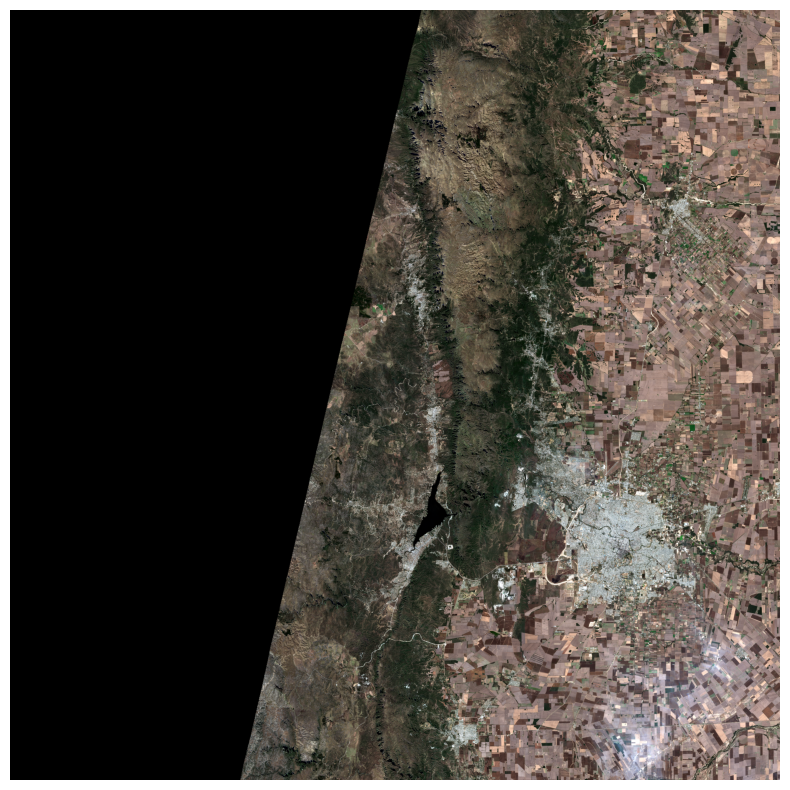

In [8]:
from matplotlib import pyplot as plt

stack_bandas_escalado = escalar_imagen_multibanda(stack_bandas.transpose(1,2,0), 1, nodata = 0)

plt.figure(figsize=(10,10))
plt.imshow(stack_bandas_escalado[:,:,[2,1,0]])
plt.axis('off')
plt.show()

### 1.5. Guardar como archivo GeoTiff

Ahora podemos guardar el archivo como GeoTiff. Le agregamos algo nuevo: Al momento de escribir, usamos `set_band_description()` para agregarle un nombre descriptivo a cada a banda, y que cuando abramos el archivo sepamos a qué banda original corresponde realmente. Esto es muy útil para tener claro cómo fue generado el archivo.

![spotUsos.png](https://drive.google.com/uc?id=17jpZSCCymU_VjfumpDmdx2lIDI7lbjLQ)

```python
from rasterio.crs import CRS
from affine import Affine

metadatos_stack = {'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0,
 'width': stack_bandas.shape[2],
 'height': stack_bandas.shape[1],
 'count': stack_bandas.shape[0],
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': Affine(10.0, 0.0, 300000.0,
        0.0, -10.0, 6600040.0)}


# Abrir el archivo en modo escritura
with rasterio.open("s2_stack_2348.tif", 'w+', **metadatos_stack) as dataset:
  for i,b in enumerate(bands_to_extract):
    dataset.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde bands_to_extract
  dataset.write(stack_bandas) #Escribir el array

```

In [9]:
from rasterio.crs import CRS
from affine import Affine

metadatos_stack = {'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0,
 'width': stack_bandas.shape[2],
 'height': stack_bandas.shape[1],
 'count': stack_bandas.shape[0],
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': Affine(10.0, 0.0, 300000.0,
        0.0, -10.0, 6600040.0)}


# Abrir el archivo en modo escritura
with rasterio.open("s2_stack_2348.tif", 'w+', **metadatos_stack) as dataset:
  for i,b in enumerate(bands_to_extract):
    dataset.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde bands_to_extract
  dataset.write(stack_bandas) #Escribir el array

### 1.6. Aplicar un recorte

Trabajar con las bandas completas puede consumir mucha memoria, con lo cual podemos aprovechar la herramienta _mask_ que ya aprendimos y un vector externo, para otener un `array` más pequeño.

```python
import geopandas as gpd


# ID del archivo de Google Drive
file_id = "1K9M1tQ84LxA7XnsNpd8YUNZFfa4rtFfC"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar la imagen
output = "poligono_s2.gpkg"
gdown.download(url, output, quiet=False)

# Leer el polígono
poligono = gpd.read_file("poligono_s2.gpkg")


#%% Generamos un nuevo stack con la extension del poligono de recorte
from rasterio.mask import mask

# Iniciamos una lista vacía para almacenar las bandas:
stack_bandas = []

for bnd in bnd_list:
    fname = f'/vsizip/{zipfilename}/{bnd}' # Agregmos /vsizip/ a cada ruta
    ds = rasterio.open(fname)
    clip, clip_transform = rasterio.mask.mask(ds, poligono.geometry, crop=True) # Extraemos una sección de la imagen solamente
    stack_bandas.append(clip[0]) # Agregamos el array recortado a stack_bandas

# Convertir la lista en array
stack_bandas = np.array(stack_bandas)
print(f'Dimensiones del nuevo array: {stack_bandas.shape}')

# Leer los metadatos
metadatos = ds.meta
```

In [10]:
import geopandas as gpd


# ID del archivo de Google Drive
file_id = "1K9M1tQ84LxA7XnsNpd8YUNZFfa4rtFfC"
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar la imagen
output = "poligono_s2.gpkg"
gdown.download(url, output, quiet=False)

# Leer el polígono
poligono = gpd.read_file("poligono_s2.gpkg")


#%% Generamos un nuevo stack con la extension del poligono de recorte
from rasterio.mask import mask

# Iniciamos una lista vacía para almacenar las bandas:
stack_bandas = []

for bnd in bnd_list:
    fname = f'/vsizip/{zipfilename}/{bnd}' # Agregmos /vsizip/ a cada ruta
    ds = rasterio.open(fname)
    clip, clip_transform = rasterio.mask.mask(ds, poligono.geometry, crop=True) # Extraemos una sección de la imagen solamente
    stack_bandas.append(clip[0]) # Agregamos el array recortado a stack_bandas

# Convertir la lista en array
stack_bandas = np.array(stack_bandas)
print(f'Dimensiones del nuevo array: {stack_bandas.shape}')

# Leer los metadatos
metadatos = ds.meta

Downloading...
From: https://drive.google.com/uc?id=1K9M1tQ84LxA7XnsNpd8YUNZFfa4rtFfC
To: /content/poligono_s2.gpkg
100%|██████████| 98.3k/98.3k [00:00<00:00, 37.0MB/s]


Dimensiones del nuevo array: (4, 593, 1080)


### 1.7. Sistematizar en una función

Podemos sistematizar los pasos para leer las bandas de cierta resolución en una función:

```python
def leer_bandas_l2a(zipfilename, bands_to_extract, res, poligono = None):
  '''Funcion para leer imagen S2 Nivel 2A desde ZIP
  Inputs: zipfilename: string, nombre del zip (ruta entera)
  bands_to_extract: Lista de bandas a extraer (Lista de strings). Ej: bands_to_extract = ['B02', 'B03', 'B04', 'B08']
  res: resolucion (ej: 10)
  poligono: poligono para aplicar recorte (en geodataframe). Por defecto no usa poligono
  '''
  zfile = ZipFile(zipfilename,'r')
  stack_bandas = []

  for bnd in zfile.namelist():
    dirname = os.path.basename(os.path.dirname(bnd))

    if dirname == f'R{res}m' and bnd.endswith('.jp2'):
        if os.path.basename(bnd).split('_')[2] in bands_to_extract:
            fname = f'/vsizip/{zipfilename}/{bnd}' # Agregmos /vsizip/ a cada ruta
            ds = rasterio.open(fname)
            metadatos = ds.meta
            if poligono is not None:
              clip, clip_transform = rasterio.mask.mask(ds, poligono.geometry, crop=True) # Extraemos una sección de la imagen solamente
              stack_bandas.append(clip[0])
              metadatos['transform'] = clip_transform # Si recortamos, actualizamos el transform de los metadatos
              metadatos['height'] = clip.shape[1] # Si recortamos, actualizamos el height de los metadatos
              metadatos['width'] = clip.shape[2] # Si recortamos, actualizamos el width de los metadatos
            else:  
              stack_bandas.append(ds.read()[0]) # Leemos como array 2D y lo agregamos a stack_bandas
  stack_bandas = np.array(stack_bandas)
  metadatos['count'] = stack_bandas.shape[0] # Actualizamos el count o numero de bandas
  metadatos['driver'] = 'GTiff' # Cambiamos el driver a GeoTiff
  return stack_bandas, metadatos
```

Esta función toma el nombre de un archivo ZIP, un listado de bandas para extraer y la resolución (carpeta) que se desea. También se puede pasar opcionalmente un polígono, en cuyo caso se actualizan los parámetros correspondientes de los metadatos.

```python
# Repetimos la extracción a 10 metros
stack_prueba_10m, metadatos_10m = leer_bandas_l2a(zipfilename, bands_to_extract =  ['B02', 'B03', 'B04', 'B08'], res = 10)
```

In [11]:
def leer_bandas_l2a(zipfilename, bands_to_extract, res, poligono = None):
  '''Funcion para leer imagen S2 Nivel 2A desde ZIP
  Inputs: zipfilename: string, nombre del zip (ruta entera)
  bands_to_extract: Lista de bandas a extraer (Lista de strings). Ej: bands_to_extract = ['B02', 'B03', 'B04', 'B08']
  res: resolucion (ej: 10)
  poligono: poligono para aplicar recorte (en geodataframe). Por defecto no usa poligono
  '''
  zfile = ZipFile(zipfilename,'r')
  stack_bandas = []

  for bnd in zfile.namelist():
    dirname = os.path.basename(os.path.dirname(bnd))

    if dirname == f'R{res}m' and bnd.endswith('.jp2'):
        if os.path.basename(bnd).split('_')[2] in bands_to_extract:
            fname = f'/vsizip/{zipfilename}/{bnd}' # Agregmos /vsizip/ a cada ruta
            ds = rasterio.open(fname)
            metadatos = ds.meta
            if poligono is not None:
              clip, clip_transform = rasterio.mask.mask(ds, poligono.geometry, crop=True) # Extraemos una sección de la imagen solamente
              stack_bandas.append(clip[0])
              metadatos['transform'] = clip_transform # Si recortamos, actualizamos el transform de los metadatos
              metadatos['height'] = clip.shape[1] # Si recortamos, actualizamos el height de los metadatos
              metadatos['width'] = clip.shape[2] # Si recortamos, actualizamos el width de los metadatos
            else:  
              stack_bandas.append(ds.read()[0]) # Leemos como array 2D y lo agregamos a stack_bandas
  stack_bandas = np.array(stack_bandas)
  metadatos['count'] = stack_bandas.shape[0] # Actualizamos el count o numero de bandas
  metadatos['driver'] = 'GTiff' # Cambiamos el driver a GeoTiff
  return stack_bandas, metadatos

In [18]:
# Repetimos la extracción a 10 metros
stack_prueba_10m, metadatos_10m = leer_bandas_l2a(zipfilename, bands_to_extract =  ['B02', 'B03', 'B04', 'B08'], res = 10, poligono=poligono)

In [19]:
stack_prueba_10m.shape

(4, 593, 1080)

A continuación, guardamos este recorte, y le pasamos los metadatos generados por la función,`metadatos_10m`, que ya tienen toda la información necesaria.

```python
# Lo guardamos:
with rasterio.open("s2_stack_2348_clip.tif", 'w+', **metadatos_10m) as dataset:
  for i,b in enumerate(bands_to_extract):
    dataset.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde bands_to_extract
  dataset.write(stack_prueba_10m) #Escribir el array   
```

In [20]:
with rasterio.open("s2_stack_2348_clip.tif", 'w+', **metadatos_10m) as dataset:
  for i,b in enumerate(bands_to_extract):
    dataset.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde bands_to_extract
  dataset.write(stack_prueba_10m) #Escribir el array 

## 2. Combinar distintas resoluciones

En las celdas anteriores, generamos `stack_prueba_10m` y `stack_prueba_20m`, con distintas resoluciones y distintas bandas. ¿Qué pasaría, por ejemplo, si quisiéramos tener un `stack` a 10 metros, que contenga `['B02', 'B03', 'B04', 'B08']` (a 10 metros) y también `['B11','B12']`, remuestradas a 10 metros?

### 2.1. Generar los stacks con las bandas de interés

Nosotros ya contamos con `stack_prueba_10m` que contiene las bandas 02,03,04,08 a 10. Podemos generar otro a 20 metros que contenga solo B11,B12 utilizando la función `leer_bandas_l2a`:

```python
stack_b11_b12, metadatos_b11_b12 = leer_bandas_l2a(zipfilename, bands_to_extract = ['B11','B12'], res = 20, poligono=poligono)
```

In [21]:
stack_b11_b12, metadatos_b11_b12 = leer_bandas_l2a(zipfilename, bands_to_extract = ['B11','B12'], res = 20, poligono=poligono)

In [22]:
stack_b11_b12.shape, stack_prueba_10m.shape

((2, 297, 541), (4, 593, 1080))

### 2.2. Remuestreo a 10 metros

Luego, podemos aplicar la siguiente función sobre `stack_b11_b12`, que usa la librería `scipy`:

```python
import scipy.ndimage

def resample_bands(src_bands,ref_bands):
    """
    Función auxiliar.
    Realiza el re-muestreo según la resolución elegida.
    """
    b = src_bands.shape[0]
    r = ref_bands.shape[1]
    c = ref_bands.shape[2]
    zf = float(r/src_bands.shape[1])
    src_resample =  np.zeros((b,r,c))
    for i,band in enumerate(src_bands):
        src_resample[i] = scipy.ndimage.zoom(src_bands[i],zf)
    return src_resample

# Remuestrar las bandas de 20 a la resolución de stack_prueba_10m
stack_b11_b12_10m = resample_bands(stack_b11_b12, stack_prueba_10m)
print('Dimensiones del stack remuestreado: {stack_b11_b12_10m.shape}')
```

In [24]:
import scipy.ndimage

def resample_bands(src_bands,ref_bands):
    """
    Función auxiliar.
    Realiza el re-muestreo según la resolución elegida.
    """
    b = src_bands.shape[0]
    r = ref_bands.shape[1]
    c = ref_bands.shape[2]
    zf = float(r/src_bands.shape[1])
    src_resample =  np.zeros((b,r,c))
    for i,band in enumerate(src_bands):
        src_resample[i] = scipy.ndimage.zoom(src_bands[i],zf)
    return src_resample

# Remuestrar las bandas de 20 a la resolución de stack_prueba_10m
stack_b11_b12_10m = resample_bands(stack_b11_b12, stack_prueba_10m)
print(f'Dimensiones del stack remuestreado: {stack_b11_b12_10m.shape}')

Dimensiones del stack remuestreado: (2, 593, 1080)


### 2.3. Juntar ambos arrays

Ahora, tenemos un `stack` con las 4 bandas originalmente a 10 metros, y otro con las 2 bandas remuestradas a esta resolución. Para juntarnos en un único `array`, podemos usar `np.concatenate` a lo largo del eje 0.

```python
stack_final = np.concatenate((stack_prueba_10m, stack_b11_b12_10m), axis = 0)
print(f'Dimensiones del stack final: {stack_final.shape}')
```

Tener presente el orden en que nos quedan las bandas: `['B02', 'B03', 'B04', 'B08', 'B11', 'B12']`

In [25]:
stack_final = np.concatenate((stack_prueba_10m, stack_b11_b12_10m), axis = 0)
print(f'Dimensiones del stack final: {stack_final.shape}')

Dimensiones del stack final: (6, 593, 1080)


### 2.4. Guardar el nuevo stack

```python
metadatos_stack_final = {'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0,
 'width': stack_final.shape[2],
 'height': stack_final.shape[1],
 'count': stack_final.shape[0],
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': metadatos_10m['transform']}

# Lista de bandas para set_band_description:
band_list = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Abrir el archivo en modo escritura
with rasterio.open("s2_stack_2-3-4-8-11-12.tif", 'w+', **metadatos_stack_final) as dataset:
  for i,b in enumerate(band_list):
    dataset.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde band_list
  dataset.write(stack_final) #Escribir el array
  ```



In [26]:
metadatos_stack_final = {'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0,
 'width': stack_final.shape[2],
 'height': stack_final.shape[1],
 'count': stack_final.shape[0],
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': metadatos_10m['transform']}

# Lista de bandas para set_band_description:
band_list = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Abrir el archivo en modo escritura
with rasterio.open("s2_stack_2-3-4-8-11-12.tif", 'w+', **metadatos_stack_final) as dataset:
  for i,b in enumerate(band_list):
    dataset.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde band_list
  dataset.write(stack_final) #Escribir el array